In [123]:
# Step 1: Import Qiskit libraries and set up Aer simulator

from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
import numpy as np

SIM = AerSimulator()

In [124]:
# Step 2: Set parameters (number of bits) — no seed, fully random each run

N_BITS = 200
rng = np.random.default_rng()   # no seed = different random values every run

In [125]:
# Step 3: Alice generates random bits and random bases (bases shown as 'Z' or 'X') # random bases: 0 = Z, 1 = X

alice_bits = rng.integers(0, 2, N_BITS)
alice_bases = rng.choice(['Z', 'X'], size=N_BITS)

print("Alice's bits  (first 10):", alice_bits[:10])
print("Alice's bases (first 10):", alice_bases[:10])

Alice's bits  (first 10): [1 1 1 1 1 1 1 0 0 1]
Alice's bases (first 10): ['X' 'Z' 'X' 'Z' 'Z' 'X' 'Z' 'X' 'Z' 'X']


In [126]:
# Step 4: Function to encode a qubit (Alice's operation)

def encode_qubit(bit, basis):
    qc = QuantumCircuit(1, 1)
    if bit == 1:
        qc.x(0)          # flip to |1> if bit is 1
    if basis == 'X':
        qc.h(0)           # switch to X basis if basis is X
    return qc

In [127]:
# Step 5: Show encoding result using state symbols |0>, |1>, |+>, |-> (verification)

state_symbols = {
    (0, 'Z'): "|0>",
    (1, 'Z'): "|1>",
    (0, 'X'): "|+>",
    (1, 'X'): "|->"
}

for i in range(10):
    bit = alice_bits[i]
    basis = alice_bases[i]
    symbol = state_symbols[(bit, basis)]
    print(f"Round {i+1}: Bit={bit}, Basis={basis}  ->  State = {symbol}")

Round 1: Bit=1, Basis=X  ->  State = |->
Round 2: Bit=1, Basis=Z  ->  State = |1>
Round 3: Bit=1, Basis=X  ->  State = |->
Round 4: Bit=1, Basis=Z  ->  State = |1>
Round 5: Bit=1, Basis=Z  ->  State = |1>
Round 6: Bit=1, Basis=X  ->  State = |->
Round 7: Bit=1, Basis=Z  ->  State = |1>
Round 8: Bit=0, Basis=X  ->  State = |+>
Round 9: Bit=0, Basis=Z  ->  State = |0>
Round 10: Bit=1, Basis=X  ->  State = |->


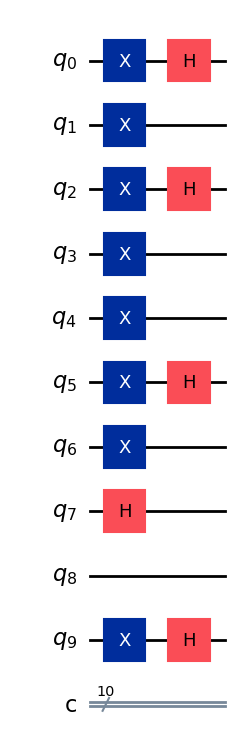

In [128]:
# Step 5(a): Display visual gate circuit for Alice's encoding (first 10 qubits)

qc_alice = QuantumCircuit(10, 10)

for i in range(10):
    if alice_bits[i] == 1:
        qc_alice.x(i)
    if alice_bases[i] == 'X':
        qc_alice.h(i)

display(qc_alice.draw('mpl'))

In [129]:
# Step 6: Bob generates random measurement bases

bob_bases = rng.choice(['Z', 'X'], size=N_BITS)

print("Bob's bases (first 10):", bob_bases[:10])

Bob's bases (first 10): ['X' 'X' 'Z' 'Z' 'Z' 'Z' 'X' 'Z' 'X' 'X']


In [130]:
# Step 7: Function to measure a qubit in Bob's chosen basis

def measure_qubit(qc, basis):
    if basis == 'X':
        qc.h(0)          # switch to X basis before measuring
    qc.measure(0, 0)
    return qc

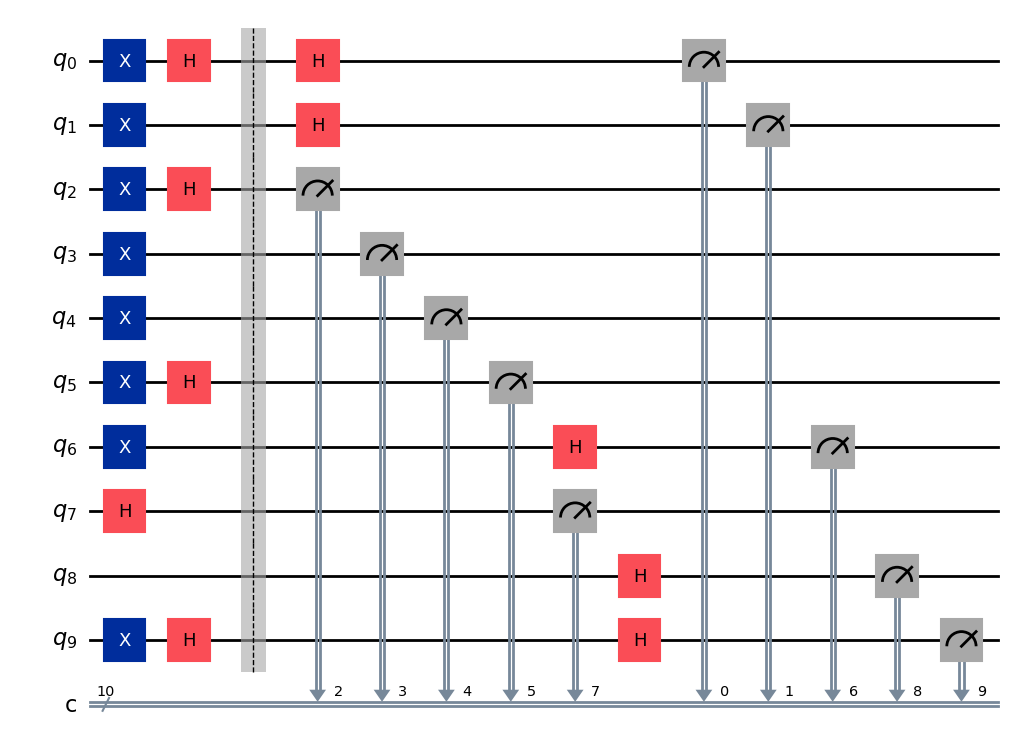

In [131]:
# Step 8: Display combined circuit — Alice's encoding + Bob's measurement (first 10 qubits)

qc_combined = QuantumCircuit(10, 10)

# ---------- Alice's part: encode bits into qubits ----------
for i in range(10):
    if alice_bits[i] == 1:
        qc_combined.x(i)
    if alice_bases[i] == 'X':
        qc_combined.h(i)

qc_combined.barrier()   # visual separator between Alice and Bob

# ---------- Bob's part: measure qubits in his chosen basis ----------
for i in range(10):
    if bob_bases[i] == 'X':
        qc_combined.h(i)
    qc_combined.measure(i, i)

display(qc_combined.draw('mpl'))

In [132]:
# Step 9: Build and run the full circuit for each qubit, collect Bob's results

bob_results = []

for i in range(N_BITS):
    qc = encode_qubit(alice_bits[i], alice_bases[i])   # Alice prepares
    qc = measure_qubit(qc, bob_bases[i])                # Bob measures
    
    result = SIM.run(qc, shots=1, memory=True).result()
    outcome = int(result.get_memory()[0])
    bob_results.append(outcome)

bob_results = np.array(bob_results)
print("Bob's results (first 10):", bob_results[:10])

Bob's results (first 10): [1 0 0 1 1 0 0 0 0 1]


In [133]:
# Step 10: Show round-by-round summary — Alice's state -> Bob's basis -> Bob's result

for i in range(10):
    symbol = state_symbols[(alice_bits[i], alice_bases[i])]
    print(f"Round {i+1}: Alice's state = {symbol}  |  Bob's basis = {bob_bases[i]}  |  Bob's result = {bob_results[i]}")

Round 1: Alice's state = |->  |  Bob's basis = X  |  Bob's result = 1
Round 2: Alice's state = |1>  |  Bob's basis = X  |  Bob's result = 0
Round 3: Alice's state = |->  |  Bob's basis = Z  |  Bob's result = 0
Round 4: Alice's state = |1>  |  Bob's basis = Z  |  Bob's result = 1
Round 5: Alice's state = |1>  |  Bob's basis = Z  |  Bob's result = 1
Round 6: Alice's state = |->  |  Bob's basis = Z  |  Bob's result = 0
Round 7: Alice's state = |1>  |  Bob's basis = X  |  Bob's result = 0
Round 8: Alice's state = |+>  |  Bob's basis = Z  |  Bob's result = 0
Round 9: Alice's state = |0>  |  Bob's basis = X  |  Bob's result = 0
Round 10: Alice's state = |->  |  Bob's basis = X  |  Bob's result = 1


In [134]:
# Step 11: Sifting — compare Alice's and Bob's bases, keep matches

sift_mask = alice_bases == bob_bases

alice_sifted = alice_bits[sift_mask]
bob_sifted = bob_results[sift_mask]

print("Sifted key length:", len(alice_sifted))
print("Alice's sifted key (first 10):", alice_sifted[:10])
print("Bob's sifted key   (first 10):", bob_sifted[:10])

Sifted key length: 100
Alice's sifted key (first 10): [1 1 1 1 0 0 0 0 1 0]
Bob's sifted key   (first 10): [1 1 1 1 0 0 0 0 1 0]


In [135]:
# Step 12: Calculate QBER on the sifted key

mismatches = np.sum(alice_sifted != bob_sifted)
qber = mismatches / len(alice_sifted)

print("Mismatches:", mismatches)
print("QBER:", qber)

Mismatches: 0
QBER: 0.0


In [136]:
# Step 13: Print/display final results

print("=" * 50)
print("BB84 - LEVEL 1 RESULT")
print("=" * 50)
print(f"Total qubits sent   : {N_BITS}")
print(f"Sifted key length   : {len(alice_sifted)}")
print(f"QBER                : {qber:.4f}")
print(f"Keys match          : {np.array_equal(alice_sifted, bob_sifted)}")

BB84 - LEVEL 1 RESULT
Total qubits sent   : 200
Sifted key length   : 100
QBER                : 0.0000
Keys match          : True


In [137]:
# Extra: Secure Key Rate (SKR) calculation

def binary_entropy(p):
    if p == 0 or p == 1:
        return 0
    return -p * np.log2(p) - (1 - p) * np.log2(1 - p)

f_EC = 1.16   # typical error-correction inefficiency factor

skr_fraction = 1 - f_EC * binary_entropy(qber) - binary_entropy(qber)
skr_fraction = max(skr_fraction, 0)   # can't be negative

final_key_length = skr_fraction * len(alice_sifted)

print(f"QBER                 : {qber:.4f}")
print(f"SKR fraction per bit : {skr_fraction:.4f}")
print(f"Estimated final secure key length : {final_key_length:.1f} bits")

QBER                 : 0.0000
SKR fraction per bit : 1.0000
Estimated final secure key length : 100.0 bits


In [138]:
# Step 2: Set parameters for LM05

N_BITS_LM05 = 200
rng_lm05 = np.random.default_rng()   # no seed = fully random each run

In [139]:
# Step 3: Bob generates random bits and random bases (initial preparation)

bob_bits_lm05 = rng_lm05.integers(0, 2, N_BITS_LM05)
bob_bases_lm05 = rng_lm05.choice(['Z', 'X'], size=N_BITS_LM05)

print("Bob's bits  (first 10):", bob_bits_lm05[:10])
print("Bob's bases (first 10):", bob_bases_lm05[:10])

Bob's bits  (first 10): [1 0 1 1 1 1 1 1 1 1]
Bob's bases (first 10): ['X' 'Z' 'X' 'Z' 'Z' 'Z' 'Z' 'Z' 'Z' 'Z']


In [140]:
# Step 4: Function to prepare Bob's qubit

def prepare_qubit(bit, basis):
    qc = QuantumCircuit(1, 1)
    if bit == 1:
        qc.x(0)          # flip to |1> if bit is 1
    if basis == 'X':
        qc.h(0)           # switch to X basis if basis is X
    return qc

In [141]:
# Step 5: Show Bob's preparation result using state symbols

state_symbols = {
    (0, 'Z'): "|0>",
    (1, 'Z'): "|1>",
    (0, 'X'): "|+>",
    (1, 'X'): "|->"
}

for i in range(10):
    bit = bob_bits_lm05[i]
    basis = bob_bases_lm05[i]
    symbol = state_symbols[(bit, basis)]
    print(f"Round {i+1}: Bit={bit}, Basis={basis}  ->  State = {symbol}")

Round 1: Bit=1, Basis=X  ->  State = |->
Round 2: Bit=0, Basis=Z  ->  State = |0>
Round 3: Bit=1, Basis=X  ->  State = |->
Round 4: Bit=1, Basis=Z  ->  State = |1>
Round 5: Bit=1, Basis=Z  ->  State = |1>
Round 6: Bit=1, Basis=Z  ->  State = |1>
Round 7: Bit=1, Basis=Z  ->  State = |1>
Round 8: Bit=1, Basis=Z  ->  State = |1>
Round 9: Bit=1, Basis=Z  ->  State = |1>
Round 10: Bit=1, Basis=Z  ->  State = |1>


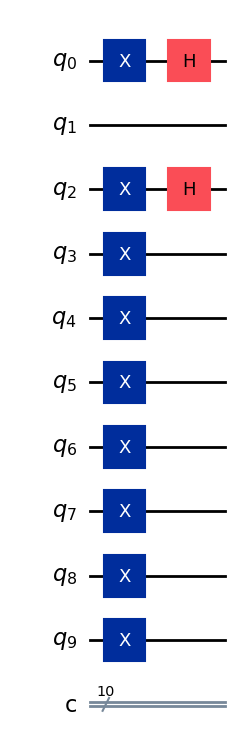

In [142]:
# Step 5(a): Display visual gate circuit for Bob's preparation (first 10 qubits)

qc_bob_prep = QuantumCircuit(10, 10)

for i in range(10):
    if bob_bits_lm05[i] == 1:
        qc_bob_prep.x(i)
    if bob_bases_lm05[i] == 'X':
        qc_bob_prep.h(i)

display(qc_bob_prep.draw('mpl'))

In [143]:
# Step 6: Alice randomly chooses mode for each round

alice_modes = rng_lm05.choice(['CM', 'MM'], size=N_BITS_LM05)

print("Alice's modes (first 10):", alice_modes[:10])

Alice's modes (first 10): ['CM' 'MM' 'CM' 'CM' 'CM' 'MM' 'CM' 'CM' 'CM' 'MM']


In [144]:
# Step 7: Alice generates random CM measurement bases (used only for CM rounds)

alice_cm_bases = rng_lm05.choice(['Z', 'X'], size=N_BITS_LM05)

print("Alice's CM bases (first 10):", alice_cm_bases[:10])

Alice's CM bases (first 10): ['Z' 'X' 'Z' 'X' 'X' 'X' 'Z' 'X' 'X' 'Z']


In [145]:
# Step 8: Alice generates random message bits to encode (used only for MM rounds)

alice_message_bits = rng_lm05.integers(0, 2, N_BITS_LM05)

print("Alice's message bits (first 10):", alice_message_bits[:10])

Alice's message bits (first 10): [0 1 0 0 1 0 0 1 0 0]


In [146]:
# Step 9: Function to apply Alice's CM measurement

def alice_cm_measure(qc, basis):
    if basis == 'X':
        qc.h(0)          # switch to X basis before measuring
    qc.measure(0, 0)
    return qc

In [147]:
# Step 10: Function to apply Alice's MM encoding (Message Mode operation)

def alice_mm_encode(qc, message_bit):
    if message_bit == 1:
        qc.y(0)          # apply sigma_y to encode bit = 1
    # if message_bit == 0, do nothing (identity)
    return qc

In [148]:
# Step 11: Function for Bob's final measurement (same basis as his original preparation)

def bob_final_measure(qc, basis):
    if basis == 'X':
        qc.h(0)          # measure in the same basis Bob originally used
    qc.measure(0, 0)
    return qc

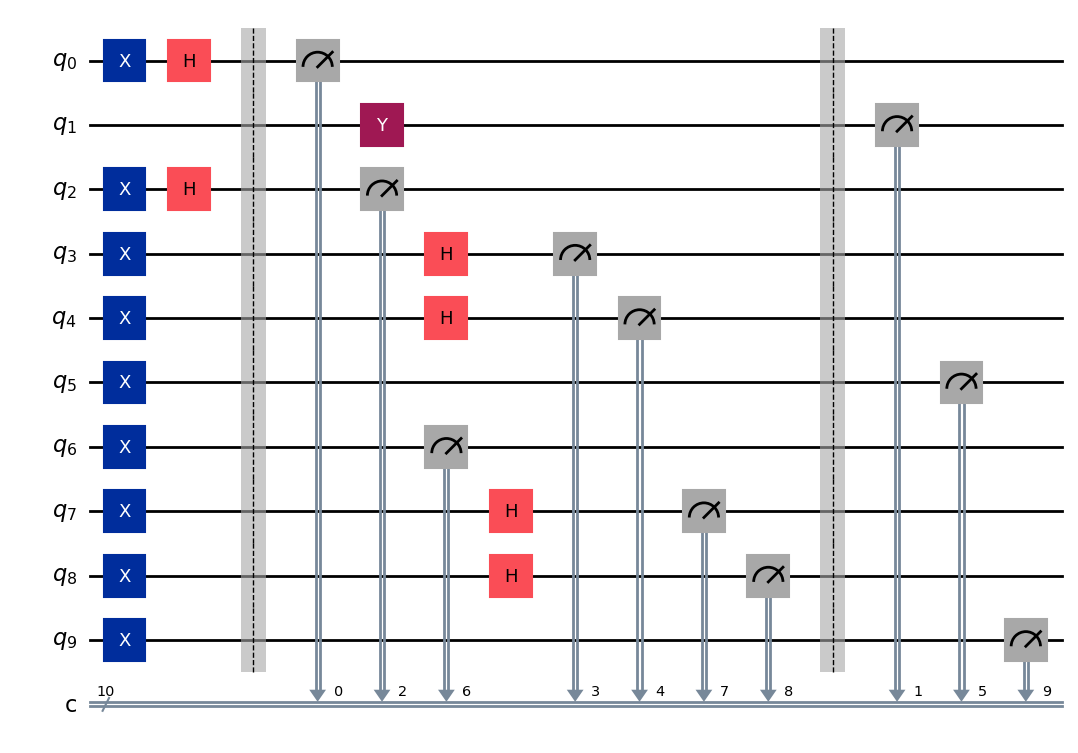

In [149]:
# Step 12: Display combined circuit — Bob's prep + Alice's operation + Bob's final measurement (first 10 qubits)

qc_lm05_combined = QuantumCircuit(10, 10)

# ---------- Bob's part: prepare qubits ----------
for i in range(10):
    if bob_bits_lm05[i] == 1:
        qc_lm05_combined.x(i)
    if bob_bases_lm05[i] == 'X':
        qc_lm05_combined.h(i)

qc_lm05_combined.barrier()   # separator: Bob's prep done

# ---------- Alice's part: CM measure or MM encode ----------
for i in range(10):
    if alice_modes[i] == 'CM':
        if alice_cm_bases[i] == 'X':
            qc_lm05_combined.h(i)
        qc_lm05_combined.measure(i, i)
    else:  # MM
        if alice_message_bits[i] == 1:
            qc_lm05_combined.y(i)

qc_lm05_combined.barrier()   # separator: Alice's part done

# ---------- Bob's part: final measurement (MM rounds only, in his original basis) ----------
for i in range(10):
    if alice_modes[i] == 'MM':
        if bob_bases_lm05[i] == 'X':
            qc_lm05_combined.h(i)
        qc_lm05_combined.measure(i, i)

display(qc_lm05_combined.draw('mpl'))

In [150]:
# Step 13: Build and run the full round-trip circuit for each qubit, collect results

cm_results = []       # Alice's CM measurement outcomes
mm_bob_decoded = []   # Bob's decoded bits (MM only)

for i in range(N_BITS_LM05):
    qc = prepare_qubit(bob_bits_lm05[i], bob_bases_lm05[i])   # Bob prepares

    if alice_modes[i] == 'CM':
        qc = alice_cm_measure(qc, alice_cm_bases[i])           # Alice measures
        result = SIM.run(qc, shots=1, memory=True).result()
        outcome = int(result.get_memory()[0])
        cm_results.append(outcome)
    else:  # MM
        qc = alice_mm_encode(qc, alice_message_bits[i])        # Alice encodes
        qc = bob_final_measure(qc, bob_bases_lm05[i])           # Bob measures
        result = SIM.run(qc, shots=1, memory=True).result()
        outcome = int(result.get_memory()[0])

        decoded_bit = 0 if outcome == bob_bits_lm05[i] else 1   # compare to original
        mm_bob_decoded.append(decoded_bit)

cm_results = np.array(cm_results)
mm_bob_decoded = np.array(mm_bob_decoded)

print("CM results (first 10):", cm_results[:10])
print("MM decoded bits (first 10):", mm_bob_decoded[:10])

CM results (first 10): [0 0 0 1 1 0 1 1 1 1]
MM decoded bits (first 10): [1 0 0 0 1 1 0 0 1 0]


In [151]:
# Step 14: Show round-by-round summary — Bob's state -> Alice's mode -> outcome

for i in range(10):
    symbol = state_symbols[(bob_bits_lm05[i], bob_bases_lm05[i])]
    mode = alice_modes[i]
    print(f"Round {i+1}: Bob's state = {symbol}  |  Mode = {mode}")

Round 1: Bob's state = |->  |  Mode = CM
Round 2: Bob's state = |0>  |  Mode = MM
Round 3: Bob's state = |->  |  Mode = CM
Round 4: Bob's state = |1>  |  Mode = CM
Round 5: Bob's state = |1>  |  Mode = CM
Round 6: Bob's state = |1>  |  Mode = MM
Round 7: Bob's state = |1>  |  Mode = CM
Round 8: Bob's state = |1>  |  Mode = CM
Round 9: Bob's state = |1>  |  Mode = CM
Round 10: Bob's state = |1>  |  Mode = MM


In [152]:
# Step 15: Control Mode check — compare Alice's CM outcome with Bob's known preparation (basis-matched only)

cm_mask = alice_modes == 'CM'

cm_bob_bits = bob_bits_lm05[cm_mask]
cm_bob_bases = bob_bases_lm05[cm_mask]
cm_alice_bases = alice_cm_bases[cm_mask]

basis_match_mask = cm_alice_bases == cm_bob_bases

cm_checkable_bob = cm_bob_bits[basis_match_mask]
cm_checkable_alice = cm_results[basis_match_mask]

print("Basis-matched CM rounds:", len(cm_checkable_alice))
print("Bob's expected bits (first 10):", cm_checkable_bob[:10])
print("Alice's CM outcomes (first 10):", cm_checkable_alice[:10])

Basis-matched CM rounds: 55
Bob's expected bits (first 10): [1 1 1 1 0 0 0 0 0 0]
Alice's CM outcomes (first 10): [1 1 1 1 0 0 0 0 0 0]


In [153]:
# Step 16: Calculate QBER from Control Mode results

cm_mismatches = np.sum(cm_checkable_alice != cm_checkable_bob)
qber_lm05 = cm_mismatches / len(cm_checkable_alice)

print("CM Mismatches:", cm_mismatches)
print("QBER (LM05):", qber_lm05)

CM Mismatches: 0
QBER (LM05): 0.0


In [154]:
# Step 17: Message Mode decoding — Bob's decoded bits from comparing his outcome to his original bit

# (decoding logic already applied in Step 13; mm_bob_decoded holds the result)

print("Bob's decoded bits (first 10):", mm_bob_decoded[:10])

Bob's decoded bits (first 10): [1 0 0 0 1 1 0 0 1 0]


In [155]:
# Step 18: Build sifted key — Alice's message bits vs Bob's decoded bits (Message Mode only)

mm_mask = alice_modes == 'MM'

alice_sifted_lm05 = alice_message_bits[mm_mask]
bob_sifted_lm05 = mm_bob_decoded

print("Sifted key length (LM05):", len(alice_sifted_lm05))
print("Alice's sifted key (first 10):", alice_sifted_lm05[:10])
print("Bob's sifted key   (first 10):", bob_sifted_lm05[:10])

Sifted key length (LM05): 97
Alice's sifted key (first 10): [1 0 0 0 1 1 0 0 1 0]
Bob's sifted key   (first 10): [1 0 0 0 1 1 0 0 1 0]


In [156]:
# Step 19: Print/display final results

print("=" * 50)
print("LM05 - LEVEL 1 RESULT")
print("=" * 50)
print(f"Total qubits sent   : {N_BITS_LM05}")
print(f"Sifted key length   : {len(alice_sifted_lm05)}")
print(f"QBER                : {qber_lm05:.4f}")
print(f"Keys match          : {np.array_equal(alice_sifted_lm05, bob_sifted_lm05)}")

LM05 - LEVEL 1 RESULT
Total qubits sent   : 200
Sifted key length   : 97
QBER                : 0.0000
Keys match          : True


In [157]:
# Step 20: Secure Key Rate (SKR) calculation

f_EC = 1.16   # typical error-correction inefficiency factor

skr_fraction_lm05 = 1 - f_EC * binary_entropy(qber_lm05) - binary_entropy(qber_lm05)
skr_fraction_lm05 = max(skr_fraction_lm05, 0)   # can't be negative

final_key_length_lm05 = skr_fraction_lm05 * len(alice_sifted_lm05)

print(f"QBER (LM05)               : {qber_lm05:.4f}")
print(f"SKR fraction per bit      : {skr_fraction_lm05:.4f}")
print(f"Estimated final secure key length : {final_key_length_lm05:.1f} bits")

QBER (LM05)               : 0.0000
SKR fraction per bit      : 1.0000
Estimated final secure key length : 97.0 bits
